<a href="https://colab.research.google.com/github/williamryanmckee-nwa/Deep-Learning/blob/main/10_07_Object_Detection_with_YOLO_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection with YOLO
- YOLO is short for You Only Look Once.
- It is a family of single-stage deep learning-based object detectors.
- They are capable of more than real-time object detection with state-of-the-art accuracy.

## Steps to  be followed:

1. Import the necessary libraries
2. Define the hyperparameter values
3. Define a helper function to download files
4. Pull the data from Roboflow
5. Clone the **YOLOv5** repository
6. Create a directory to store results
7. Run the model
8. Define a function to show validation predictions saved during training
9. Define a helper function for inference on images
10. Visualize inference images



### Step 1: Import the necessary libraries
- Import the **os** module for operating system-related functionalities.
- Import the **glob** module for file path pattern matching.
- Import the **matplotlib.pyplot** module for plotting.
- Import the **OpenCV** module for image processing.
- Import the **requests** module for making HTTP requests.


In [22]:
import os
import glob as glob
import matplotlib.pyplot as plt
import cv2
import requests

### Step 2: Define the hyperparameter values
- Define the number of epochs to train.

In [23]:
TRAIN = True
EPOCHS = 5

__Observations:__

The code specifies that the training will be conducted over a total of 5 epochs.

### Step 3: Define a helper function to download files
- Download a file from the provided URL and save it with the specified name.
- Send an HTTP GET request to the URL to download the file.
- Write the content of the response to a file using the specified name.
- If the file already exists, display a message indicating that the download has been skipped.


In [24]:
def download_file(url, save_name):
    if not os.path.exists(save_name):
        file = requests.get(url)
        open(save_name, 'wb').write(file.content)
    else:
        print('File already present, skipping download...')

### About the dataset:
- The dataset comprises images depicting different vehicles in diverse traffic conditions. These images have been sourced from the Open Image dataset.
- In total, the dataset consists of 5 classes, namely: Car, Bus, Motorcycle, Truck, and Ambulance.

### Step 4: Pull the data from Roboflow
Roboflow is an end-to-end computer vision platform that simplifies the process of building computer vision models.

-  If the **train** directory doesn't exist, download the dataset zip file from the specified URL using curl.
- Unzip the downloaded file and remove the zip file after extraction.
- Create a list of directory names: **train, valid, test**.
- Iterate over each directory name and its corresponding index.
- Get a sorted list of all image names in the current directory.
- Iterate over each image name and its corresponding index.
- If the index is even (i.e., every second image), extract the file name without the extension.
- Remove the image file.
- Remove the corresponding label file.

In [25]:
if not os.path.exists('train'):
    os.system('curl -L "https://public.roboflow.com/ds/xKLV14HbTF?key=aJzo7msVta" > roboflow.zip')
    os.system('unzip roboflow.zip; rm roboflow.zip')
    dirs = ['train', 'valid', 'test']
    for dir_name in dirs:
        all_image_names = sorted(os.listdir(f"{dir_name}/images/"))
        for j, image_name in enumerate(all_image_names):
            if (j % 2) == 0:
                file_name = image_name.split('.jpg')[0]
                os.remove(f"{dir_name}/images/{image_name}")
                os.remove(f"{dir_name}/labels/{file_name}.txt")

**Observations:**

The code snippet downloads a dataset, extracts it, and selectively removes certain image and label files from the directories.

### Step 5: Clone the YOLOv5 repository
- If the **YOLOv5** directory does not exist, clone the **YOLOv5** repository from the provided GitHub URL.
- Change the current working directory to **YOLOv5**.
- Install the necessary Python packages listed in the **requirements.txt** file.

In [26]:

if not os.path.exists('yolov5'):
    os.system('git clone https://github.com/ultralytics/yolov5.git')
os.chdir('yolov5')
os.system('pip3 install -r requirements.txt')

0

**Observations:**

The code block checks for the presence of the **YOLOv5** project directory, clones it (if necessary), sets it as the current working directory, and installs the required dependencies.

### Step 6: Create a directory to store results
- Set the directory to store results based on the current number of result directories.
- Count the number of result directories in the **runs/train** directory. If the **TRAIN** variable is **True** (assuming it's defined outside of this function), then set the result directory name with an incremented count.
- Otherwise, set the result directory name without incrementing the count.
- Return the name of the result directory.


In [27]:
def set_res_dir():
    # Directory to store results
    res_dir_count = len(glob.glob('runs/train/*'))
    print(f"Current number of result directories: {res_dir_count}")
    if TRAIN:
        RES_DIR = f"results_{res_dir_count+1}"
    else:
        RES_DIR = f"results_{res_dir_count}"
    return RES_DIR


### Step 7: Run the model
- Set the **RES_DIR** variable by calling the **set_res_dir()** function.
- If the **TRAIN** variable is **True**, execute the **train.py** script with the specified command-line arguments.


In [28]:
RES_DIR = set_res_dir()
print(RES_DIR)
if TRAIN:
    print(os.getcwd())
    #os.chdir('/work/yolov5') # Change to yolov5 directory
    os.system(f'python3 train.py --data ../data.yaml --weights yolov5s.pt '
              f'--img 320 --epochs {EPOCHS} --batch-size 8 --name {RES_DIR}')
    os.chdir('..') # Change back to the original directory

Current number of result directories: 0
results_1
/content/yolov5/yolov5


### Step 8: Define a function to show validation predictions saved during training
- List the contents of the **runs/train/{RES_DIR}** directory.
- Set the **EXP_PATH** variable as the path to the result directory.
- Get a list of paths to predicted images in the result directory.
- Print the list of predicted image paths.
- Iterate over each predicted image path.
- Read the image using **OpenCV**.
- Create a figure with a specific size.
- Display the image (converting BGR to RGB) and turn off the axes.
- Show the image.


In [29]:
def show_valid_results(RES_DIR):
    !ls yolov5/runs/train/{RES_DIR}
    EXP_PATH = f"yolov5/runs/train/{RES_DIR}"
    validation_pred_images = glob.glob(f"{EXP_PATH}/*_pred.jpg")
    print(validation_pred_images)
    for pred_image in validation_pred_images:
        image = cv2.imread(pred_image)
        plt.figure(figsize=(19, 16))
        plt.imshow(image[:, :, ::-1])
        plt.axis('off')
        plt.show()

### Step 9: Define a helper function for inference on images
- Perform inference on images using the specified result directory.
- Create a directory to store inference results.
- Count the number of inference-detection directories.
- Set the inference-detection directory name with an incremented count.
- Execute the **detect.py** script with the specified command-line arguments.
- Return the name of the inference detection directory.


In [30]:
def inference(RES_DIR, data_path):
    import glob, os

    # Count how many detect runs already exist
    detect_runs = glob.glob('yolov5/runs/detect/*')
    infer_dir_count = len(detect_runs)
    print(f"Current number of inference detection directories: {infer_dir_count}")

    # Name of the next results folder (just the folder name!)
    INFER_DIR_NAME = f"inference_{infer_dir_count + 1}"
    print("Output folder name:", INFER_DIR_NAME)

    # --- Step 1: move into yolov5 directory ---
    cwd = os.getcwd()
    os.chdir('yolov5')

    # --- Step 2: run YOLOv5 detect ---
    os.system(
        f'python3 detect.py '
        f'--weights runs/train/{RES_DIR}/weights/best.pt '
        f'--source ../{data_path} '
        f'--name {INFER_DIR_NAME}'
    )

    # --- Step 3: return to original directory ---
    os.chdir(cwd)

    # Full absolute path to the folder where results are stored
    full_output_path = f'/yolov5/runs/detect/{INFER_DIR_NAME}'
    return full_output_path


### Step 10: Visualize inference images
- Perform inference on images using the specified result directory.
- Create a directory to store inference results.
- Count the number of inference-detection directories.
- Set the inference detection directory name with an incremented count.
- Execute the **detect.py** script with the specified command-line arguments and return the name of the inference detection directory.



In [31]:
def visualize(INFER_DIR):

    INFER_PATH = f"runs/detect/{INFER_DIR}"
    infer_images = glob.glob(f"{INFER_PATH}/*.jpg")
    print(infer_images)
    for pred_image in infer_images:
        image = cv2.imread(pred_image)
        plt.figure(figsize=(19, 16))
        plt.imshow(image[:, :, ::-1])
        plt.axis('off')
        plt.show()

confusion_matrix.png				    results.png
events.out.tfevents.1790818325.6f396da5feec.3880.0  train_batch0.jpg
F1_curve.png					    train_batch1.jpg
hyp.yaml					    train_batch2.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
opt.yaml					    val_batch1_labels.jpg
P_curve.png					    val_batch1_pred.jpg
PR_curve.png					    val_batch2_labels.jpg
R_curve.png					    val_batch2_pred.jpg
results.csv					    weights
['yolov5/runs/train/results_1/val_batch2_pred.jpg', 'yolov5/runs/train/results_1/val_batch1_pred.jpg', 'yolov5/runs/train/results_1/val_batch0_pred.jpg']


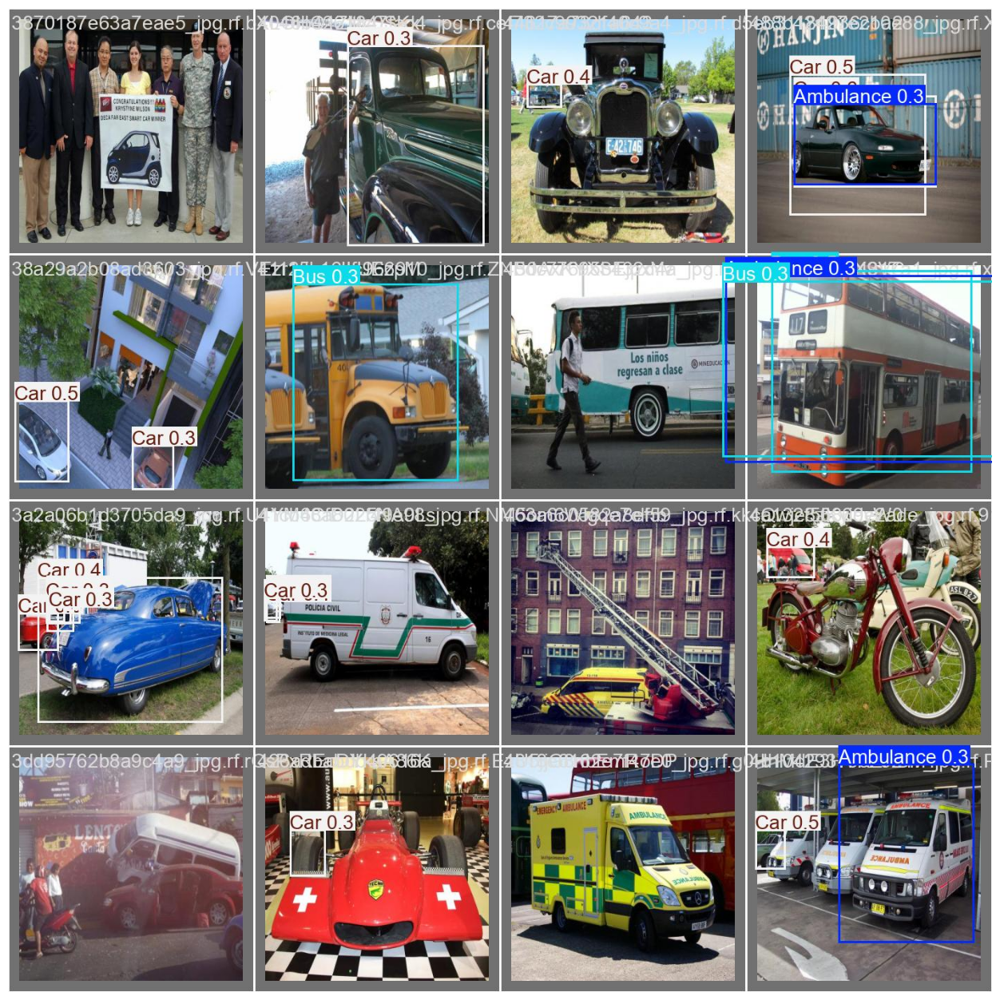

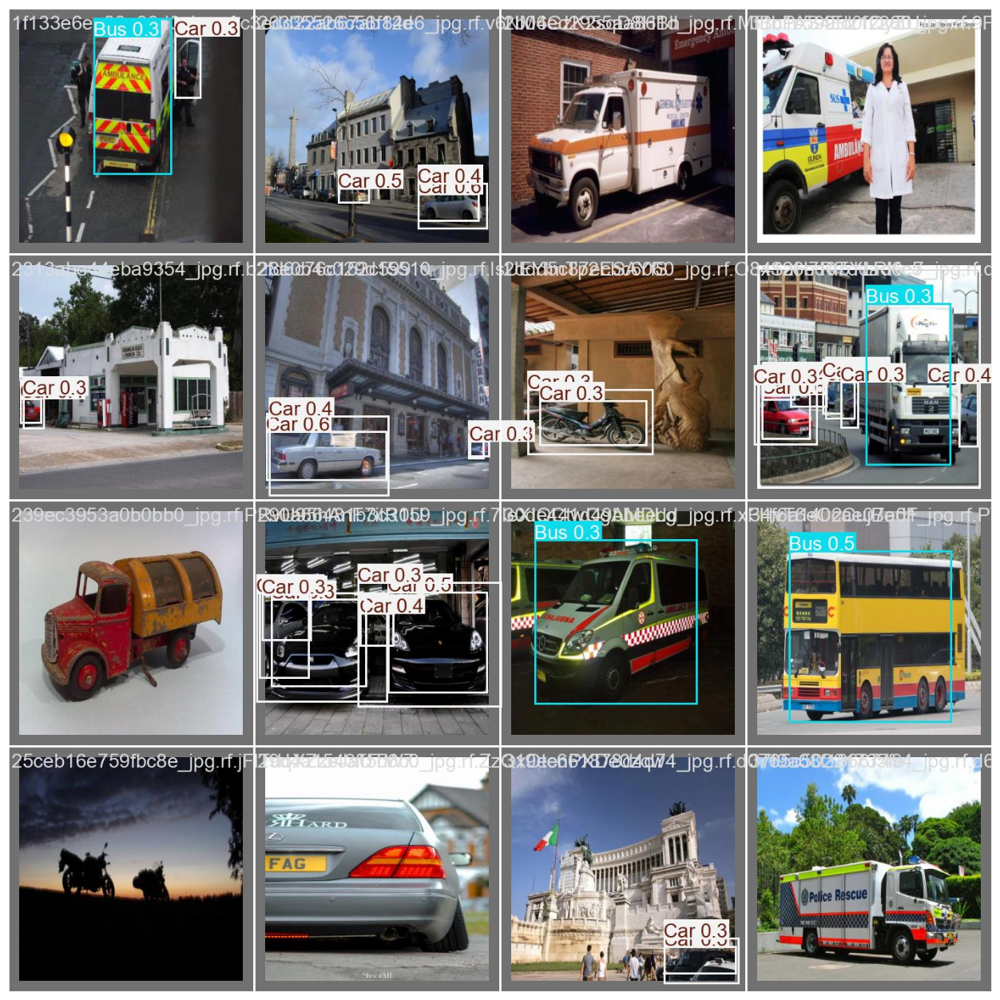

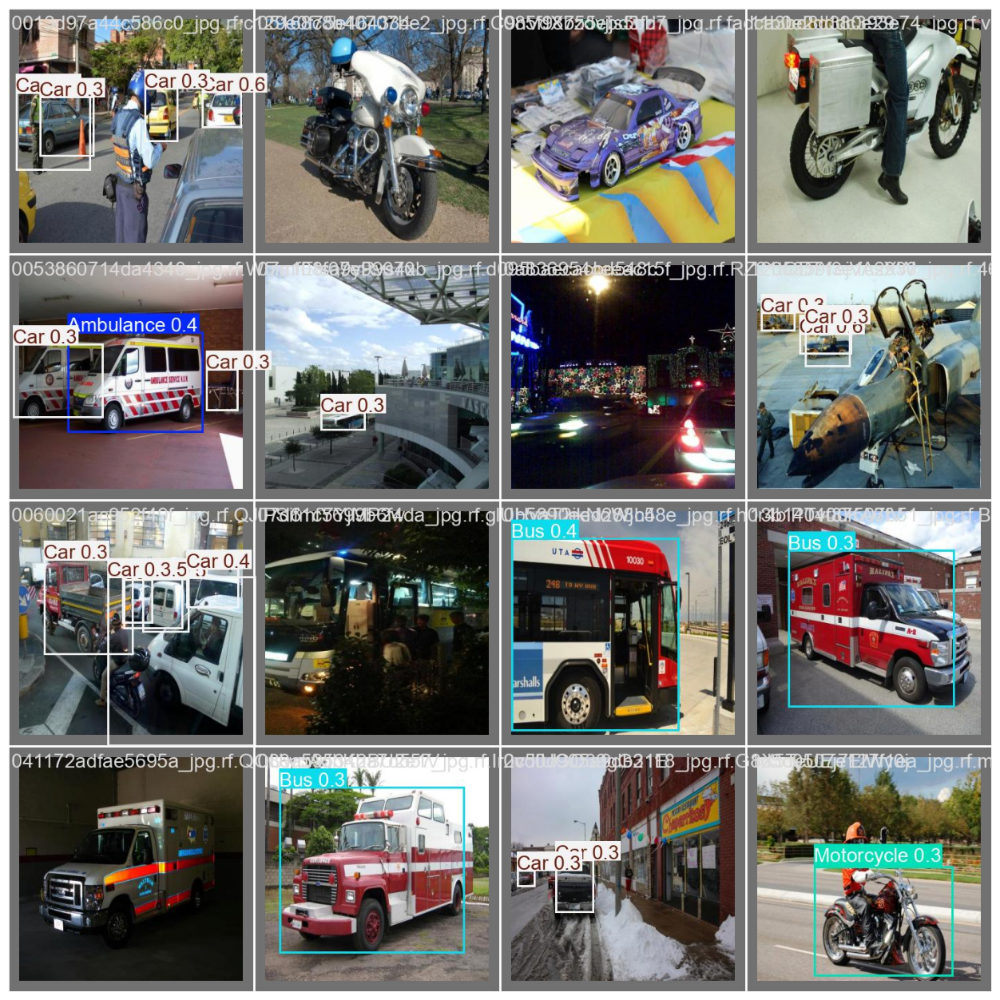

In [32]:
show_valid_results(RES_DIR)

**Observations:**

The code defines a function that retrieves inference images from a specified directory. It loads and visualizes each image using OpenCV and Matplotlib, respectively, and displays them.

#### Download the inference data file
- If the **inference_images** directory doesn't exist, extract the contents of the **inference_data.zip** file.
- Else, print a message indicating that the dataset is already present.


In [33]:
download_file('https://learnopencv.s3.us-west-2.amazonaws.com/yolov5_inference_data.zip',
              'inference_data.zip')
if not os.path.exists('inference_images'):
    !unzip -q "inference_data.zip"
else:
    print('Dataset already present')

#### Inference on images
- Call the **inference** function with the arguments **RES_DIR** and **inference_images**.
- Assign the output to the variable **IMAGE_INFER_DIR**.

In [34]:
IMAGE_INFER_DIR = inference('results_1', 'inference_images')
print("Results saved in:", IMAGE_INFER_DIR)

Current number of inference detection directories: 0
Output folder name: inference_1
Results saved in: /yolov5/runs/detect/inference_1


#### Visualizing the inference results
- Invoke the **visualize** function and pass the variable **IMAGE_INFER_DIR** as an argument.
- The visualize function displays the contents of the directory or file represented by the **IMAGE_INFER_DIR** variable.

In [35]:
import glob
import cv2
import matplotlib.pyplot as plt

def visualize_inference(infer_dir_path):
    """
    Show all images saved in the YOLOv5 detection output folder.
    infer_dir_path: absolute path returned by inference(), e.g.
                    'yolov5/runs/detect/inference_1'
    """
    # Find all jpg / png images in the folder
    images = sorted(
        glob.glob(f"{infer_dir_path}/*.jpg") +
        glob.glob(f"{infer_dir_path}/*.png")
    )

    if not images:
        print("No images found in", infer_dir_path)
        return

    print(f"Found {len(images)} images. Displaying them:")

    for img_path in images:
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read {img_path}")
            continue
        # Convert BGR (OpenCV) to RGB (matplotlib)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
        plt.show()


Found 4 images. Displaying them:


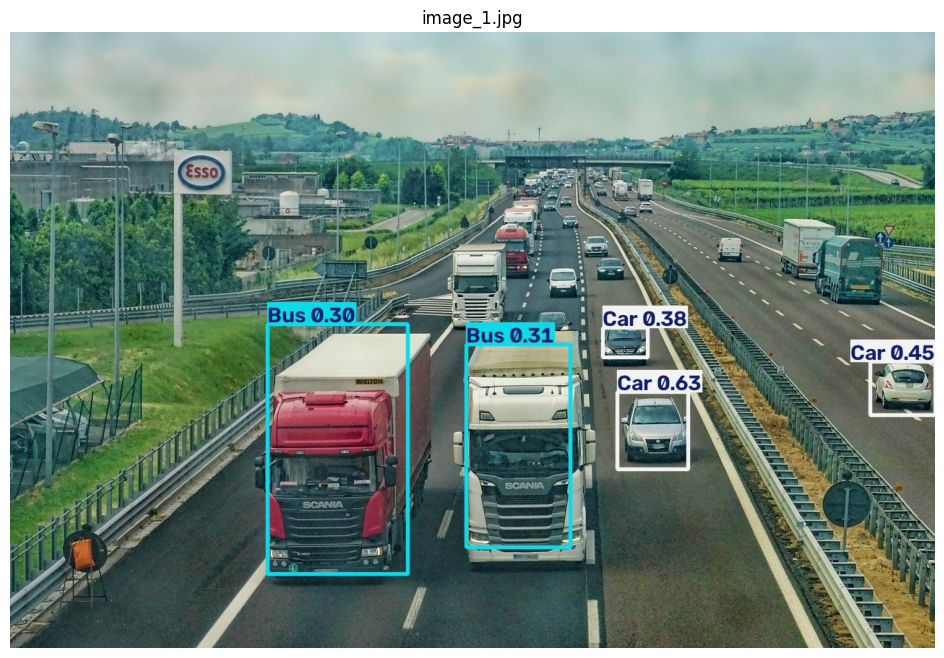

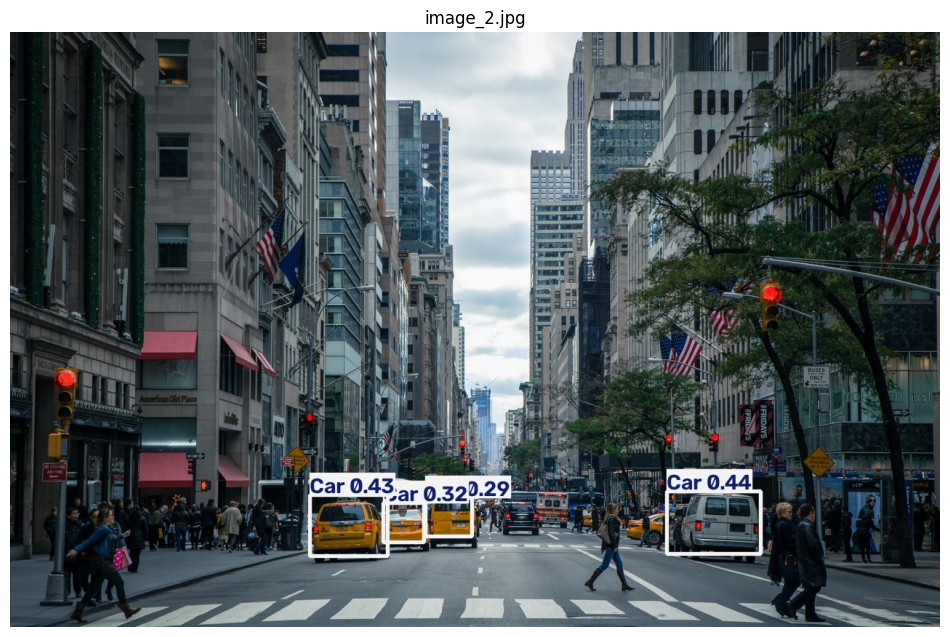

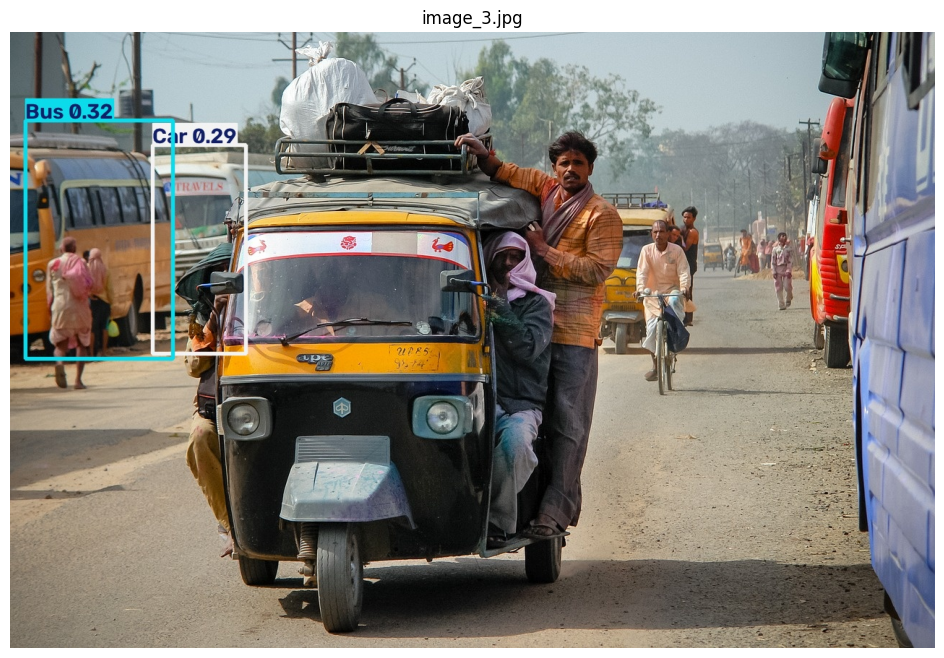

In [ ]:
visualize_inference("yolov5/runs/detect/inference_1")

**Observations:**

 The content associated with the directory or file is displayed.